In [116]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/raw/marketing_roi_dataset.csv",
    parse_dates=["date"]
)

df = df.sort_values("date").reset_index(drop=True)

In [117]:
# Only uses current & past info
df["revenue_diff"] = df["revenue"].diff()

threshold = df["revenue"].std() * 0.5

df["target_up_big"] = (df["revenue_diff"] > threshold).astype(int)

# Drop rows created by diff
df = df.dropna().reset_index(drop=True)

In [118]:
features = [
    "google_ads_spend",
    "facebook_ads_spend",
    "email_marketing_spend",
    "influencer_spend",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions"
]

df_features = df[["date"] + features + ["target_up_big"]].copy()

In [119]:
df_diff = df_features.copy()

for col in features:
    df_diff[f"{col}_diff"] = df_diff[col].diff()

# Drop original columns (important for clarity)
df_diff = df_diff.drop(columns=features)

df_diff = df_diff.dropna().reset_index(drop=True)

In [120]:
split_idx = int(len(df_diff) * 0.8)

train = df_diff.iloc[:split_idx]
test = df_diff.iloc[split_idx:]

X_train = train.drop(columns=["target_up_big", "date"])
y_train = train["target_up_big"]

X_test = test.drop(columns=["target_up_big", "date"])
y_test = test["target_up_big"]

In [121]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [122]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]

In [123]:
results = {
    "RF_Accuracy": accuracy_score(y_test, rf_pred),
    "RF_AUC": roc_auc_score(y_test, rf_prob),
    "GB_Accuracy": accuracy_score(y_test, gb_pred),
    "GB_AUC": roc_auc_score(y_test, gb_prob)
}

results

{'RF_Accuracy': 0.6240601503759399,
 'RF_AUC': 0.5265060240963856,
 'GB_Accuracy': 0.5939849624060151,
 'GB_AUC': 0.4720481927710844}

In [124]:
print(X_train.columns)

Index(['google_ads_spend_diff', 'facebook_ads_spend_diff',
       'email_marketing_spend_diff', 'influencer_spend_diff',
       'organic_traffic_diff', 'email_sends_diff', 'site_visits_diff',
       'conversions_diff'],
      dtype='object')


In [125]:
def get_feature_importance(model, feature_names):
    return dict(zip(feature_names, model.feature_importances_))

In [126]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/marketing_roi_dataset.csv", parse_dates=["date"])

# Always sort
df = df.sort_values("date").reset_index(drop=True)

In [127]:
# Base spend columns (raw)
base_spend_cols = [
    "google_ads_spend",
    "facebook_ads_spend",
    "email_marketing_spend",
    "influencer_spend"
]

# If raw exists but log doesn't → create log
for col in base_spend_cols:
    log_col = f"{col}_log"
    
    if col in df.columns and log_col not in df.columns:
        df[log_col] = np.log1p(df[col])  # safe log

In [128]:
spend_cols = [c for c in df.columns if c.endswith("_log")]

print("Using spend columns:", spend_cols)

Using spend columns: ['google_ads_spend_log', 'facebook_ads_spend_log', 'email_marketing_spend_log', 'influencer_spend_log']


In [129]:
# Total spend
df["total_spend"] = df[spend_cols].sum(axis=1)

# Share features
for col in spend_cols:
    df[f"{col}_share"] = df[col] / (df["total_spend"] + 1e-5)

In [130]:
# -------------------
# LAGS
# -------------------
for col in spend_cols + ["revenue"]:
    for lag in [1, 3, 7]:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

# -------------------
# ROLLING
# -------------------
for col in spend_cols + ["revenue"]:
    df[f"{col}_roll7"] = df[col].rolling(7).mean()

# -------------------
# MOMENTUM
# -------------------
df["revenue_diff"] = df["revenue"].diff()
df["revenue_momentum_3"] = df["revenue"].diff(3)

# -------------------
# TARGETS
# -------------------
# Basic direction
df["target_up"] = (df["revenue_diff"] > 0).astype(int)

# Big moves
threshold = df["revenue_diff"].std()
df["target_big_up"] = (df["revenue_diff"] > threshold).astype(int)

# Multi-class
df["target_multi"] = pd.cut(
    df["revenue_diff"],
    bins=[-np.inf, -threshold, threshold, np.inf],
    labels=[0, 1, 2]
)

# -------------------
# DROP NA FROM LAGS
# -------------------
df = df.iloc[7:]
for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].median())

df_model = df.dropna().copy()

In [140]:
len(df_model)

993

In [133]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import ParameterGrid

# Optional (if installed)
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False


def run_experiment(df, target_col):

    # -------------------
    # PREP DATA
    # -------------------
    drop_cols = [
    col for col in df.columns
    if ("revenue" in col.lower()) or ("target" in col.lower())
    ]

    X = df.drop(columns=drop_cols + ["date"], errors="ignore")
    
    # REMOVE leakage
    X = X[[col for col in X.columns if "revenue" not in col]]

    y = df[target_col]

    X = X.select_dtypes(include=[np.number])

    # Time split
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    results = []

    # -------------------
    # RANDOM FOREST GRID
    # -------------------
    rf_grid = {
        "n_estimators": [200, 500],
        "max_depth": [4, 8],
        "min_samples_leaf": [1, 5]
    }

    for params in ParameterGrid(rf_grid):
        model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        importances = get_feature_importance(model, X_train.columns)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        res = {
            "model": "RF",
            "target": target_col,   # <-- MUST stay inside function
            **params,
            "accuracy": accuracy_score(y_test, y_pred),
            "auc": roc_auc_score(y_test, y_prob[:, 1]) if len(np.unique(y)) == 2 else np.nan,
            "feature_importance": importances
        }

        # AUC only for binary
        if len(np.unique(y)) == 2:
            res["auc"] = roc_auc_score(y_test, y_prob[:, 1])
        else:
            res["auc"] = np.nan

        results.append(res)

    # -------------------
    # GRADIENT BOOSTING
    # -------------------
    gb_grid = {
        "n_estimators": [200, 500],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    }

    for params in ParameterGrid(gb_grid):
        model = GradientBoostingClassifier(**params, random_state=42)
        model.fit(X_train, y_train)
        importances = get_feature_importance(model, X_train.columns)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        res = {
            "model": "RF",
            "target": target_col,   # <-- MUST stay inside function
            **params,
            "accuracy": accuracy_score(y_test, y_pred),
            "auc": roc_auc_score(y_test, y_prob[:, 1]) if len(np.unique(y)) == 2 else np.nan,
            "feature_importance": importances
        }

        if len(np.unique(y)) == 2:
            res["auc"] = roc_auc_score(y_test, y_prob[:, 1])
        else:
            res["auc"] = np.nan

        results.append(res)

    # -------------------
    # XGBOOST (if available)
    # -------------------
    if xgb_available:
        xgb_grid = {
            "n_estimators": [300],
            "max_depth": [3, 5],
            "learning_rate": [0.05, 0.1]
        }

        for params in ParameterGrid(xgb_grid):
            model = XGBClassifier(
                **params,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )

            model.fit(X_train, y_train)
            importances = get_feature_importance(model, X_train.columns)

            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)

            res = {
                "model": "RF",
                "target": target_col,   # <-- MUST stay inside function
                **params,
                "accuracy": accuracy_score(y_test, y_pred),
                "auc": roc_auc_score(y_test, y_prob[:, 1]) if len(np.unique(y)) == 2 else np.nan,
                "feature_importance": importances
            }

            if len(np.unique(y)) == 2:
                res["auc"] = roc_auc_score(y_test, y_prob[:, 1])
            else:
                res["auc"] = np.nan

            results.append(res)

    return pd.DataFrame(results)

In [134]:
all_results = []

targets = ["target_up", "target_big_up"]

for target in targets:
    res = run_experiment(df_model, target)
    all_results.append(res)

final_results = pd.concat(all_results)

# Sort by best models
final_results = final_results.sort_values(
    by=["auc", "accuracy"], ascending=False
)

final_results.head(20)

,model,target,max_depth,min_samples_leaf,n_estimators,accuracy,auc,feature_importance,learning_rate
11,RF,target_up,5,NaN,500,0.572864,0.593756,"{'google_ads_spend': 0.013330585257966288, 'facebook_ads_spend': 0.02164413118235593, 'email_marketing_spend': 0.009430043689060842, 'influencer_spend': 0.019595531162359372, 'organic_traffic': 0.04148557048748196, 'email_sends': 0.039917697077610906, 'site_visits': 0.023577206379383552, 'conversions': 0.05591080986650764, 'google_ads_spend_log': 0.018277930095809424, 'facebook_ads_spend_log': 0.016628482214051856, 'email_marketing_spend_log': 0.013398791333835001, 'influencer_spend_log': 0.013233804820787213, 'total_spend': 0.05255255032917383, 'google_ads_spend_log_share': 0.021084772978290922, 'facebook_ads_spend_log_share': 0.018522322513612344, 'email_marketing_spend_log_share': 0.030772065514091108, 'influencer_spend_log_share': 0.022120841406070953, 'google_ads_spend_log_lag1': 0.06782131892221545, 'google_ads_spend_log_lag3': 0.026937680306795574, 'google_ads_spend_log_lag7': 0.030188567349125804, 'facebook_ads_spend_log_lag1': 0.037036309817483674, 'facebook_ads_spend_log_lag3': 0.03674647403766751, 'facebook_ads_spend_log_lag7': 0.04942607813679134, 'email_marketing_spend_log_lag1': 0.02664234218182569, 'email_marketing_spend_log_lag3': 0.022079113306951757, 'email_marketing_spend_log_lag7': 0.046807044346185454, 'influencer_spend_log_lag1': 0.026286611054066496, 'influencer_spend_log_lag3': 0.05096799557900854, 'influencer_spend_log_lag7': 0.0434302403373112, 'google_ads_spend_log_roll7': 0.02602831321366703, 'facebook_ads_spend_log_roll7': 0.017379991733453937, 'email_marketing_spend_log_roll7': 0.036735849123531075, 'influencer_spend_log_roll7': 0.02400293424547028}",0.05
6,RF,target_up,8,5.0,200,0.537688,0.588907,"{'google_ads_spend': 0.03476861342010875, 'facebook_ads_spend': 0.02853485299894773, 'email_marketing_spend': 0.022926663833649063, 'influencer_spend': 0.028057339807027955, 'organic_traffic': 0.03499652321136007, 'email_sends': 0.03218580353710274, 'site_visits': 0.02611405303521922, 'conversions': 0.03162349640316946, 'google_ads_spend_log': 0.036757651073671294, 'facebook_ads_spend_log': 0.03496024646208842, 'email_marketing_spend_log': 0.023453391938887826, 'influencer_spend_log': 0.028157168471168406, 'total_spend': 0.04386074086334627, 'google_ads_spend_log_share': 0.028698971000066433, 'facebook_ads_spend_log_share': 0.021808628948999736, 'email_marketing_spend_log_share': 0.031923023400668375, 'influencer_spend_log_share': 0.03339368657880633, 'google_ads_spend_log_lag1': 0.06504879755809237, 'google_ads_spend_log_lag3': 0.027352449328278964, 'google_ads_spend_log_lag7': 0.026067859664212215, 'facebook_ads_spend_log_lag1': 0.04157572576393176, 'facebook_ads_spend_log_lag3': 0.02109617611742189, 'facebook_ads_spend_log_lag7': 0.034431833182070416, 'email_marketing_spend_log_lag1': 0.028824510837854214, 'email_marketing_spend_log_lag3': 0.030042198655209365, 'email_marketing_spend_log_lag7': 0.02334987741693005, 'influencer_spend_log_lag1': 0.023731360475098353, 'influencer_spend_log_lag3': 0.03724013552078576, 'influencer_spend_log_lag7': 0.03506627621558206, 'google_ads_spend_log_roll7': 0.01965013294585369, 'facebook_ads_spend_log_roll7': 0.019508399547524723, 'email_marketing_spend_log_roll7': 0.019944516923288667, 'influencer_spend_log_roll7': 0.02484889486357747}",NaN
7,RF,target_up,8,5.0,500,0.522613,0.586381,"{'google_ads_spend': 0.030828475194125526, 'facebook_ads_spend': 0.03230479751635, 'email_marketing_spend': 0.021591070591212742, 'influencer_spend': 0.029196118544806044, 'organic_traffic': 0.03296347898309116, 'email_sends': 0.030064170782742778, 'site_visits': 0.024727438261291385, 'conversions': 0.0290046196560726, 'google_ads_spend_log': 0.03576704144748943, 'facebook_ads_spend_log': 0.03306321607512928, 'email_marketing_spend_log': 0.022370137205980852, 'influencer_spend_log': 0.032018835758987965, 'total_spend': 0.04557124981060155, 'g

In [135]:
final_results

,model,target,max_depth,min_samples_leaf,n_estimators,accuracy,auc,feature_importance,learning_rate
11,RF,target_up,5,NaN,500,0.572864,0.593756,"{'google_ads_spend': 0.013330585257966288, 'facebook_ads_spend': 0.02164413118235593, 'email_marketing_spend': 0.009430043689060842, 'influencer_spend': 0.019595531162359372, 'organic_traffic': 0.04148557048748196, 'email_sends': 0.039917697077610906, 'site_visits': 0.023577206379383552, 'conversions': 0.05591080986650764, 'google_ads_spend_log': 0.018277930095809424, 'facebook_ads_spend_log': 0.016628482214051856, 'email_marketing_spend_log': 0.013398791333835001, 'influencer_spend_log': 0.013233804820787213, 'total_spend': 0.05255255032917383, 'google_ads_spend_log_share': 0.021084772978290922, 'facebook_ads_spend_log_share': 0.018522322513612344, 'email_marketing_spend_log_share': 0.030772065514091108, 'influencer_spend_log_share': 0.022120841406070953, 'google_ads_spend_log_lag1': 0.06782131892221545, 'google_ads_spend_log_lag3': 0.026937680306795574, 'google_ads_spend_log_lag7': 0.030188567349125804, 'facebook_ads_spend_log_lag1': 0.037036309817483674, 'facebook_ads_spend_log_lag3': 0.03674647403766751, 'facebook_ads_spend_log_lag7': 0.04942607813679134, 'email_marketing_spend_log_lag1': 0.02664234218182569, 'email_marketing_spend_log_lag3': 0.022079113306951757, 'email_marketing_spend_log_lag7': 0.046807044346185454, 'influencer_spend_log_lag1': 0.026286611054066496, 'influencer_spend_log_lag3': 0.05096799557900854, 'influencer_spend_log_lag7': 0.0434302403373112, 'google_ads_spend_log_roll7': 0.02602831321366703, 'facebook_ads_spend_log_roll7': 0.017379991733453937, 'email_marketing_spend_log_roll7': 0.036735849123531075, 'influencer_spend_log_roll7': 0.02400293424547028}",0.05
6,RF,target_up,8,5.0,200,0.537688,0.588907,"{'google_ads_spend': 0.03476861342010875, 'facebook_ads_spend': 0.02853485299894773, 'email_marketing_spend': 0.022926663833649063, 'influencer_spend': 0.028057339807027955, 'organic_traffic': 0.03499652321136007, 'email_sends': 0.03218580353710274, 'site_visits': 0.02611405303521922, 'conversions': 0.03162349640316946, 'google_ads_spend_log': 0.036757651073671294, 'facebook_ads_spend_log': 0.03496024646208842, 'email_marketing_spend_log': 0.023453391938887826, 'influencer_spend_log': 0.028157168471168406, 'total_spend': 0.04386074086334627, 'google_ads_spend_log_share': 0.028698971000066433, 'facebook_ads_spend_log_share': 0.021808628948999736, 'email_marketing_spend_log_share': 0.031923023400668375, 'influencer_spend_log_share': 0.03339368657880633, 'google_ads_spend_log_lag1': 0.06504879755809237, 'google_ads_spend_log_lag3': 0.027352449328278964, 'google_ads_spend_log_lag7': 0.026067859664212215, 'facebook_ads_spend_log_lag1': 0.04157572576393176, 'facebook_ads_spend_log_lag3': 0.02109617611742189, 'facebook_ads_spend_log_lag7': 0.034431833182070416, 'email_marketing_spend_log_lag1': 0.028824510837854214, 'email_marketing_spend_log_lag3': 0.030042198655209365, 'email_marketing_spend_log_lag7': 0.02334987741693005, 'influencer_spend_log_lag1': 0.023731360475098353, 'influencer_spend_log_lag3': 0.03724013552078576, 'influencer_spend_log_lag7': 0.03506627621558206, 'google_ads_spend_log_roll7': 0.01965013294585369, 'facebook_ads_spend_log_roll7': 0.019508399547524723, 'email_marketing_spend_log_roll7': 0.019944516923288667, 'influencer_spend_log_roll7': 0.02484889486357747}",NaN
7,RF,target_up,8,5.0,500,0.522613,0.586381,"{'google_ads_spend': 0.030828475194125526, 'facebook_ads_spend': 0.03230479751635, 'email_marketing_spend': 0.021591070591212742, 'influencer_spend': 0.029196118544806044, 'organic_traffic': 0.03296347898309116, 'email_sends': 0.030064170782742778, 'site_visits': 0.024727438261291385, 'conversions': 0.0290046196560726, 'google_ads_spend_log': 0.03576704144748943, 'facebook_ads_spend_log': 0.03306321607512928, 'email_marketing_spend_log': 0.022370137205980852, 'influencer_spend_log': 0.032018835758987965, 'total_spend': 0.04557124981060155, 'g

Dive deeper into RF classifiers that show strong AUC

In [136]:
# Set options to display all rows, columns, and full column width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # For long strings

In [137]:
import pandas as pd
import numpy as np

df_model = df_model.copy()

target = "target_up"

# -------------------
# FEATURES + TARGET FROM SAME DF
# -------------------
drop_cols = [
    col for col in df_model.columns
    if ("revenue" in col.lower()) or ("target" in col.lower())
]

X = df_model.drop(columns=drop_cols + ["date"], errors="ignore")

# extra safety
X = X.select_dtypes(include=[np.number])

y = df_model[target]

# -------------------
# TIME SPLIT (NOW ALIGNED)
# -------------------
split = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [138]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import roc_auc_score, accuracy_score

rf_grid = {
    "n_estimators": [200, 400, 800],
    "max_depth": [6, 8, 10, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "max_features": ["sqrt", 0.5, 0.8]
}

results = []

for params in ParameterGrid(rf_grid):
    
    model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    results.append({
        **params,
        "auc": roc_auc_score(y_test, y_prob),
        "accuracy": accuracy_score(y_test, y_pred)
    })

rf_results = pd.DataFrame(results).sort_values(by="auc", ascending=False)

rf_results.head(10)

,max_depth,max_features,min_samples_leaf,n_estimators,auc,accuracy
111,NaN,sqrt,3,200,0.600525,0.562814
112,NaN,sqrt,3,400,0.598404,0.547739
43,8.0,sqrt,5,400,0.589311,0.517588
42,8.0,sqrt,5,200,0.588907,0.537688
21,6.0,0.5,10,200,0.587593,0.522613
128,NaN,0.5,5,800,0.586583,0.527638
113,NaN,sqrt,3,800,0.586381,0.542714
39,8.0,sqrt,3,200,0.586381,0.537688
90,10.0,0.5,5,200,0.586381,0.512563
127,NaN,0.5,5,400,0.586179,0.537688


In [139]:
best_params = rf_results.iloc[0][rf_grid.keys()].to_dict()

# Fix types
if "max_depth" in best_params and best_params["max_depth"] is not None:
    best_params["max_depth"] = int(best_params["max_depth"])

if "min_samples_leaf" in best_params:
    best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])

if "n_estimators" in best_params:
    best_params["n_estimators"] = int(best_params["n_estimators"])

best_model = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

y_prob = best_model.predict_proba(X_test)[:, 1]

ValueError: cannot convert float NaN to integer

In [ ]:
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Top features
top_features = feat_imp.head(20).index.tolist()

feat_imp.head(20)

google_ads_spend_log_lag1          0.056444
email_sends                        0.054258
influencer_spend_log_lag7          0.041283
influencer_spend_log_lag3          0.040231
facebook_ads_spend_log_lag1        0.038940
email_marketing_spend_log_lag7     0.038680
facebook_ads_spend_log_lag7        0.036288
site_visits                        0.033324
google_ads_spend_log_lag3          0.032335
facebook_ads_spend_log_roll7       0.032166
organic_traffic                    0.031347
conversions                        0.031291
email_marketing_spend_log_roll7    0.030860
email_marketing_spend_log_share    0.030853
influencer_spend_log_roll7         0.030126
total_spend                        0.030101
facebook_ads_spend                 0.029974
google_ads_spend_log_roll7         0.029558
facebook_ads_spend_log_lag3        0.027929
facebook_ads_spend_log             0.027678
dtype: float64

In [ ]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

best_model.fit(X_train_top, y_train)

y_prob_top = best_model.predict_proba(X_test_top)[:, 1]

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_top)

# Find best threshold
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print("Optimal threshold:", optimal_threshold)

Optimal threshold: 0.4969593568437184


In [ ]:
y_pred_opt = (y_prob_top >= optimal_threshold).astype(int)

final_auc = roc_auc_score(y_test, y_prob_top)
final_acc = accuracy_score(y_test, y_pred_opt)

print("Final AUC:", final_auc)
print("Final Accuracy (optimized):", final_acc)

Final AUC: 0.7852941176470589
Final Accuracy (optimized): 0.7567567567567568


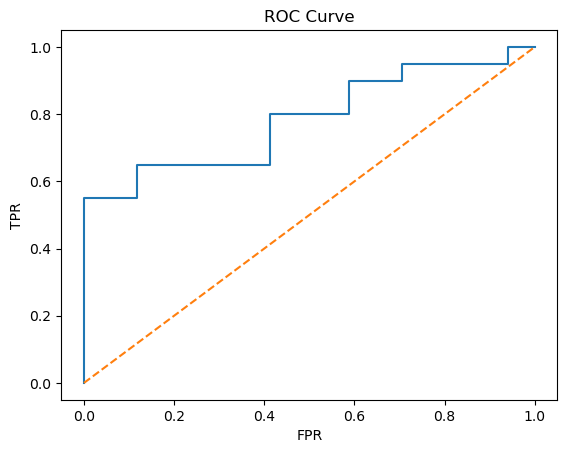

In [ ]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

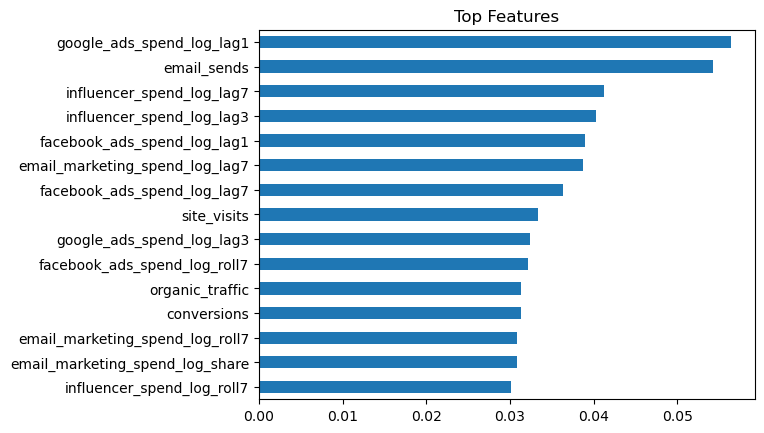

In [ ]:
feat_imp.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

Code to prevent data leakage

In [ ]:
import numpy as np
import pandas as pd

def prepare_features(df, target_col, allow_revenue_lags=False):
    
    df = df.copy().dropna()
    
    target_cols = ["target_up", "target_big_up", "target_multi"]
    
    y = df[target_col]
    
    X = df.drop(columns=target_cols + ["date"], errors="ignore")
    
    # Remove revenue leakage
    if allow_revenue_lags:
        allowed = ["revenue_lag1", "revenue_lag3", "revenue_lag7"]
        X = X[[c for c in X.columns if ("revenue" not in c) or (c in allowed)]]
    else:
        X = X[[c for c in X.columns if "revenue" not in c]]
    
    X = X.select_dtypes(include=[np.number])
    
    return X, y

In [ ]:
def time_split(X, y, split=0.8):
    idx = int(len(X) * split)
    return X.iloc[:idx], X.iloc[idx:], y.iloc[:idx], y.iloc[idx:]

In [ ]:
from sklearn.metrics import accuracy_score

def optimize_threshold(y_true, y_prob):
    thresholds = np.linspace(0.1, 0.9, 50)
    
    best_acc = 0
    best_thresh = 0.5
    
    for t in thresholds:
        preds = (y_prob > t).astype(int)
        acc = accuracy_score(y_true, preds)
        
        if acc > best_acc:
            best_acc = acc
            best_thresh = t
    
    return best_thresh, best_acc

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def tune_random_forest(X_train, y_train, X_test, y_test):
    
    param_grid = {
        "n_estimators": [200, 500],
        "max_depth": [4, 6, 8],
        "min_samples_leaf": [1, 5]
    }
    
    results = []
    
    for n in param_grid["n_estimators"]:
        for d in param_grid["max_depth"]:
            for leaf in param_grid["min_samples_leaf"]:
                
                rf = RandomForestClassifier(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_leaf=leaf,
                    random_state=42,
                    n_jobs=-1
                )
                
                rf.fit(X_train, y_train)
                
                y_prob = rf.predict_proba(X_test)[:, 1]
                
                auc = roc_auc_score(y_test, y_prob)
                thresh, acc = optimize_threshold(y_test, y_prob)
                
                results.append({
                    "model": rf,
                    "auc": auc,
                    "accuracy": acc,
                    "threshold": thresh,
                    "params": (n, d, leaf)
                })
    
    results_df = pd.DataFrame(results)
    
    best_row = results_df.sort_values("auc", ascending=False).iloc[0]
    
    return best_row

In [ ]:
def select_top_features(model, X_train, top_n=10):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    top_features = importances.sort_values(ascending=False).head(top_n).index.tolist()
    return top_features

In [ ]:
def run_full_pipeline(datasets, target_col="target_up"):
    
    final_results = []
    
    for name, df in datasets.items():
        
        print(f"\nRunning dataset: {name}")
        
        # Prepare features
        X, y = prepare_features(df, target_col)
        
        # Split
        X_train, X_test, y_train, y_test = time_split(X, y)
        
        # Tune RF
        best = tune_random_forest(X_train, y_train, X_test, y_test)
        
        model = best["model"]
        
        # Feature selection
        top_features = select_top_features(model, X_train, top_n=10)
        
        # Retrain with top features
        model.fit(X_train[top_features], y_train)
        
        y_prob = model.predict_proba(X_test[top_features])[:, 1]
        
        auc = roc_auc_score(y_test, y_prob)
        thresh, acc = optimize_threshold(y_test, y_prob)
        
        final_results.append({
            "dataset": name,
            "auc": auc,
            "accuracy": acc,
            "threshold": thresh,
            "features": top_features,
            "model": model
        })
    
    results_df = pd.DataFrame(final_results).sort_values("auc", ascending=False)
    
    best_overall = results_df.iloc[0]
    
    return results_df, best_overall

In [ ]:
df = pd.read_csv(
    "../data/raw/marketing_roi_dataset.csv",
    parse_dates=["date"]
)

df = df.sort_values("date").reset_index(drop=True)
# Fill missing values (simple + consistent)
for col in df.columns:
    if col != "date":
        df[col] = df[col].fillna(df[col].median())
# Predict whether revenue goes UP tomorrow
df["revenue_diff"] = df["revenue"].diff()
df["target_up"] = (df["revenue_diff"] > 0).astype(int)

df = df.dropna().reset_index(drop=True)
df_raw = df.copy()

In [ ]:
lag_cols = [
    "google_ads_spend",
    "facebook_ads_spend",
    "email_marketing_spend",
    "influencer_spend",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions",
    "revenue"
]

df_lag = df.copy()

for col in lag_cols:
    for lag in [1, 2, 3, 4, 5, 6, 7]:
        df_lag[f"{col}_lag{lag}"] = df_lag[col].shift(lag)

df_lag = df_lag.dropna().reset_index(drop=True)

In [ ]:
df_roll = df.copy()

for col in lag_cols:
    df_roll[f"{col}_roll7"] = df_roll[col].rolling(7).mean()

df_roll = df_roll.dropna().reset_index(drop=True)

In [ ]:
df_diff = df.copy()

for col in lag_cols:
    df_diff[f"{col}_diff"] = df_diff[col].diff()

df_diff = df_diff.dropna().reset_index(drop=True)

In [ ]:
df_narrow = df[[
    "google_ads_spend",
    "facebook_ads_spend",
    "email_sends",
    "conversions",
    "target_up"
]].copy()

In [ ]:
datasets = {
    "raw": df_raw,
    "lag": df_lag,
    "diff": df_diff,
    "rolling": df_roll,
    "narrow": df_narrow
}

results_df, best_model_info = run_full_pipeline(datasets, target_col="target_up")

print(results_df[["dataset", "auc", "accuracy", "threshold"]])


Running dataset: raw

Running dataset: lag

Running dataset: diff

Running dataset: rolling

Running dataset: narrow
   dataset       auc  accuracy  threshold
2     diff  0.624362  0.610000   0.442857
1      lag  0.604971  0.608040   0.475510
0      raw  0.563156  0.560000   0.459184
3  rolling  0.553748  0.552764   0.475510
4   narrow  0.519552  0.560000   0.475510
